# Crack Detection MobileNetV3Large
Transfer Learning + Fine-Tuning untuk klasifikasi retakan: Diagonal, Horizontal, Vertikal.



In [1]:
%pip install tensorflow scikit-learn matplotlib seaborn numpy pillow -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenetv3_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from PIL import Image
import random

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU tersedia       : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version : 2.19.0
GPU tersedia       : False


## Konfigurasi

In [3]:
DATASET_DIR = './dataset'
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 50
NUM_CLASSES = 3
CLASS_NAMES = ['Diagonal', 'Horizontal', 'Vertikal']
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
SEED        = 42

MODEL_NAME  = 'MobileNetV3Large'

print(f'Dataset  : {DATASET_DIR}')
print(f'Img Size : {IMG_SIZE}')
print(f'Model    : {MODEL_NAME}')

Dataset  : ./dataset
Img Size : (224, 224)
Model    : MobileNetV3Large


## Dataset

## Distribusi Dataset (Horizontal / Vertikal / Diagonal)


In [ ]:
## ─────────────────────────────────────────────────────────────────
## Distribusi Dataset: Horizontal / Vertikal / Diagonal
## ─────────────────────────────────────────────────────────────────
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

DATASET_DIR  = './dataset'
CLASS_NAMES  = ['Diagonal', 'Horizontal', 'Vertikal']
MODEL_NAME   = 'MobileNetV3Large'

# Hitung jumlah gambar per kelas
counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.exists(cls_path):
        n = len([f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
        counts[cls] = n
    else:
        counts[cls] = 0

total = sum(counts.values())
COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Distribusi Dataset — {MODEL_NAME}', fontsize=14, fontweight='bold', y=1.02)

# ── 1. Bar chart ─────────────────────────────────────────────────
bars = axes[0].bar(counts.keys(), counts.values(), color=COLORS, edgecolor='black', linewidth=0.8)
axes[0].set_title('Jumlah Gambar per Kelas', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kelas Retakan', fontsize=11)
axes[0].set_ylabel('Jumlah Gambar', fontsize=11)
axes[0].set_ylim(0, max(counts.values()) * 1.15)
for bar, (k, v) in zip(bars, counts.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 5, str(v),
                 ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── 2. Pie chart ─────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    counts.values(), labels=counts.keys(),
    autopct='%1.1f%%', colors=COLORS, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Proporsi Dataset (%)', fontsize=12, fontweight='bold')

# ── 3. Stacked bar train/val/test ────────────────────────────────
TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = 0.70, 0.15, 0.15
x = np.arange(len(CLASS_NAMES))
w = 0.5
train_n = [int(counts[c] * TRAIN_SPLIT) for c in CLASS_NAMES]
val_n   = [int(counts[c] * VAL_SPLIT)   for c in CLASS_NAMES]
test_n  = [counts[c] - train_n[i] - val_n[i] for i, c in enumerate(CLASS_NAMES)]

b1 = axes[2].bar(x, train_n, w, label='Train (70%)',      color='#6C5CE7', edgecolor='black', linewidth=0.6)
b2 = axes[2].bar(x, val_n,   w, label='Validasi (15%)',   color='#FDCB6E', edgecolor='black', linewidth=0.6, bottom=train_n)
b3 = axes[2].bar(x, test_n,  w, label='Test (15%)',       color='#00B894', edgecolor='black', linewidth=0.6,
                 bottom=[train_n[i]+val_n[i] for i in range(len(CLASS_NAMES))])
axes[2].set_title('Pembagian Train/Val/Test per Kelas', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Kelas Retakan', fontsize=11)
axes[2].set_ylabel('Jumlah Gambar', fontsize=11)
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'distribusi_dataset_mobilenetv3large.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Total dataset : {total} gambar")
for cls, n in counts.items():
    pct = n/total*100
    print(f"    {cls:12s}: {n:4d} gambar  ({pct:.1f}%)")
print(f"\n  Train ~{int(total*TRAIN_SPLIT)} | Val ~{int(total*VAL_SPLIT)} | Test ~{int(total*TEST_SPLIT)}")


## Load & Split Dataset (70/15/15)

In [5]:
all_images, all_labels = [], []
for label_idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATASET_DIR, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            all_images.append(os.path.join(cls_path, fname))
            all_labels.append(label_idx)

combined = list(zip(all_images, all_labels))
random.seed(SEED)
random.shuffle(combined)
all_images, all_labels = zip(*combined)
all_images = list(all_images)
all_labels = list(all_labels)

X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels,
    test_size=(VAL_SPLIT + TEST_SPLIT),
    random_state=SEED, stratify=all_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5,
    random_state=SEED, stratify=y_temp
)

print(f'  Train      : {len(X_train):4d} gambar ({len(X_train)/len(all_images)*100:.1f}%)')
print(f'  Validation : {len(X_val):4d} gambar ({len(X_val)/len(all_images)*100:.1f}%)')
print(f'  Test       : {len(X_test):4d} gambar ({len(X_test)/len(all_images)*100:.1f}%)')

  Train      : 1078 gambar (70.0%)
  Validation :  231 gambar (15.0%)
  Test       :  232 gambar (15.1%)


## Preprocessing & Augmentasi



In [ ]:
RESIZE_TO   = 256   # resize shortest side ke 256 
CROP_SIZE   = 224   # final crop ke 224x224


def resize_preserve_aspect(img):
    """Resize agar sisi terpendek menjadi RESIZE_TO, pertahankan aspek rasio."""
    shape   = tf.shape(img)
    h       = tf.cast(shape[0], tf.float32)
    w       = tf.cast(shape[1], tf.float32)

    scale   = tf.cast(RESIZE_TO, tf.float32) / tf.minimum(h, w)

    new_h   = tf.cast(tf.round(h * scale), tf.int32)
    new_w   = tf.cast(tf.round(w * scale), tf.int32)

    new_h   = tf.maximum(new_h, RESIZE_TO)
    new_w   = tf.maximum(new_w, RESIZE_TO)

    img     = tf.image.resize(img, [new_h, new_w],
                              method=tf.image.ResizeMethod.BILINEAR)
    return img


def center_crop(img):
    shape  = tf.shape(img)
    h, w   = shape[0], shape[1]
    offset_h = (h - CROP_SIZE) // 2
    offset_w = (w - CROP_SIZE) // 2
    img    = tf.image.crop_to_bounding_box(img, offset_h, offset_w,
                                           CROP_SIZE, CROP_SIZE)
    return img

def load_and_resize(path, label):
    img   = tf.io.read_file(path)
    img   = tf.image.decode_image(img, channels=3, expand_animations=False)
    img   = tf.cast(img, tf.float32)          # [0, 255]
    img   = resize_preserve_aspect(img)        # shortest side = 256
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def train_crop_and_augment(img, label):
    # Random crop: posisi crop random di dalam area 256x256
    img = tf.image.random_crop(img, size=[CROP_SIZE, CROP_SIZE, 3])


    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k=k)

    # Augmentasi warna ringan
    img = tf.image.random_brightness(img, max_delta=0.2 * 255.0)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label


def val_test_crop(img, label):
    img = center_crop(img)
    return img, label


def apply_normalize(img, label):
    img = mobilenetv3_preprocess(img)
    return img, label

def make_dataset(paths, labels, is_training=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_resize, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        ds = ds.map(train_crop_and_augment, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(val_test_crop, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.map(apply_normalize, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=500, seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(X_train, y_train, is_training=True,  shuffle=True)
val_ds   = make_dataset(X_val,   y_val,   is_training=False, shuffle=False)
test_ds  = make_dataset(X_test,  y_test,  is_training=False, shuffle=False)

print(f'  Train batches      : {len(train_ds)}')
print(f'  Validation batches : {len(val_ds)}')
print(f'  Test batches       : {len(test_ds)}')
print()
print('  Augmentasi Training:')
print('  - Random crop (256 -> 224)')
print('  - Random flip horizontal & vertikal')
print('  - Random rotasi 90 derajat (0/90/180/270)')
print('  - Random brightness & contrast')



## Build Model MobileNetV3Large

 Unfreeze 40% layer terakhir (proporsional).  
Learning rate `1e-5` untuk MobileNet.

In [ ]:
def build_mobilenetv3():
    base = MobileNetV3Large(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze semua layer dahulu
    base.trainable = False

    #  Unfreeze 40% layer terakhir (proporsional, bukan angka absolut)
    n_layers      = len(base.layers)
    unfreeze_from = int(n_layers * 0.6)  # unfreeze dari indeks 60% sampai akhir
    for layer in base.layers[unfreeze_from:]:
        layer.trainable = True

    print(f'  Total layer backbone : {n_layers}')
    print(f'  Layer yang di-unfreeze: {n_layers - unfreeze_from} ({(1-0.6)*100:.0f}%)')

    inputs = keras.Input(shape=(*IMG_SIZE, 3))

    # training=True agar BatchNorm di backbone terupdate saat fine-tuning
    x = base(inputs, training=True)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=MODEL_NAME)

    # LR lebih kecil (1e-5) untuk mencegah merusak pretrained weights MobileNet
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    total_p = model.count_params()
    train_p = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f'  Total params     : {total_p:,}')
    print(f'  Trainable params : {train_p:,}')
    return model

model = build_mobilenetv3()

  Total layer backbone : 187
  Layer yang di-unfreeze: 75 (40%)
  Total params     : 3,279,491
  Trainable params : 3,021,867


## Training

In [8]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(filepath=f'best_{MODEL_NAME}.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 287ms/step - accuracy: 0.3762 - loss: 1.5123 - val_accuracy: 0.2987 - val_loss: 1.2897 - learning_rate: 1.0000e-05
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 248ms/step - accuracy: 0.3883 - loss: 1.4305 - val_accuracy: 0.3030 - val_loss: 1.2736 - learning_rate: 1.0000e-05
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 267ms/step - accuracy: 0.4515 - loss: 1.2565 - val_accuracy: 0.3420 - val_loss: 1.2328 - learning_rate: 1.0000e-05
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 250ms/step - accuracy: 0.4520 - loss: 1.2062 - val_accuracy: 0.3420 - val_loss: 1.1792 - learning_rate: 1.0000e-05
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.5227 - loss: 1.0888 - val_accuracy: 0.3983 - val_loss: 1.1208 - learning_rate: 1.0000e-05
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 270ms/step - accuracy: 0.5297 - loss: 1.0152 - val_accuracy: 0.4329 - val_loss: 1.0567 - learning_rate: 1.0000e-05
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 269ms/step - acc

## Grafik Training History

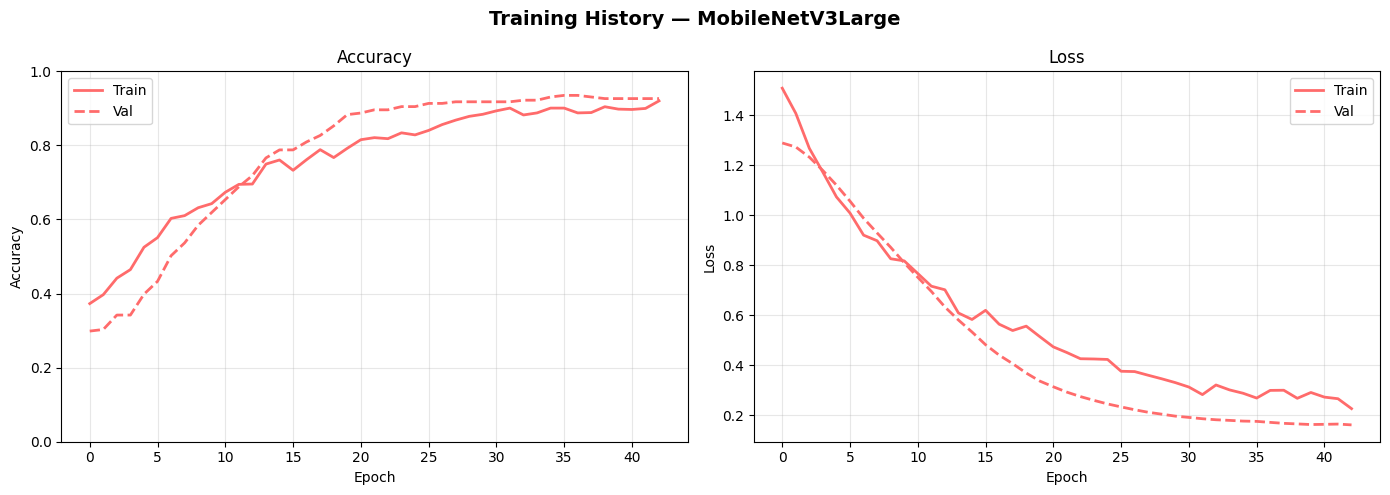

In [9]:
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Training History — {MODEL_NAME}', fontsize=14, fontweight='bold')
color = '#FF6B6B'

axes[0].plot(history.history['accuracy'], label='Train', color=color, linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val', color=color, linewidth=2, linestyle='--')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].plot(history.history['loss'], label='Train', color=color, linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val', color=color, linewidth=2, linestyle='--')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'training_history_{MODEL_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluasi pada Test Set

In [10]:
loss, acc = model.evaluate(test_ds, verbose=1)
print(f'\n  Test Loss     : {loss:.4f}')
print(f'  Test Accuracy : {acc*100:.2f}%')


y_true_all, y_pred_all = [], []
for imgs, labels in test_ds:
    y_true_all.extend(np.argmax(labels.numpy(), axis=1))
    preds = model.predict(imgs, verbose=0)
    y_pred_all.extend(np.argmax(preds, axis=1))
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.9416 - loss: 0.2462

  Test Loss     : 0.2423
  Test Accuracy : 93.10%


## Confusion Matrix

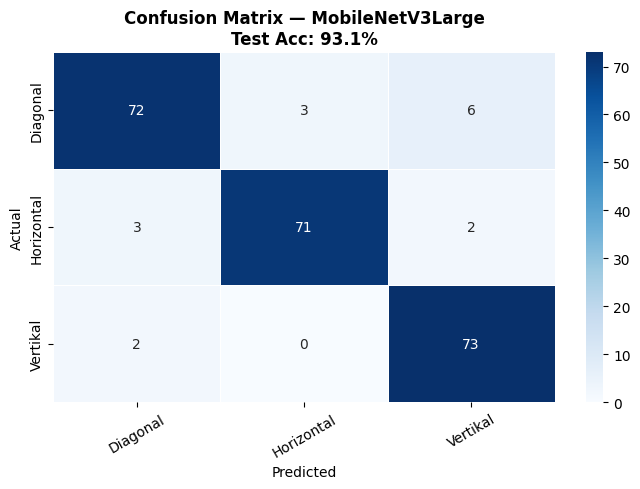

In [11]:
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', linewidths=0.5)
plt.title(f'Confusion Matrix — {MODEL_NAME}\nTest Acc: {acc*100:.1f}%', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'confusion_matrix_{MODEL_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

## Classification Report

In [12]:
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES))

import pandas as pd
best_val_acc = max(history.history['val_accuracy'])
df_result = pd.DataFrame([{
    'Model'       : MODEL_NAME,
    'Val Acc (%)' : f'{best_val_acc*100:.2f}',
    'Test Acc (%)': f'{acc*100:.2f}',
    'Precision'   : f'{precision_score(y_true_all, y_pred_all, average="macro")*100:.2f}',
    'Recall'      : f'{recall_score(y_true_all, y_pred_all, average="macro")*100:.2f}',
    'F1-Score'    : f'{f1_score(y_true_all, y_pred_all, average="macro")*100:.2f}',
}])
print(df_result.to_string(index=False))
df_result.to_csv(f'hasil_{MODEL_NAME}.csv', index=False)

              precision    recall  f1-score   support

    Diagonal       0.94      0.89      0.91        81
  Horizontal       0.96      0.93      0.95        76
    Vertikal       0.90      0.97      0.94        75

    accuracy                           0.93       232
   macro avg       0.93      0.93      0.93       232
weighted avg       0.93      0.93      0.93       232

           Model Val Acc (%) Test Acc (%) Precision Recall F1-Score
MobileNetV3Large       93.51        93.10     93.19  93.21    93.13


## Uji Gambar Capture drone

Loading TFLite model: cracksense_MobileNetV3Large.tflite
  Input  : shape=[  1 224 224   3], dtype=<class 'numpy.float32'>
  Output : shape=[1 3], dtype=<class 'numpy.float32'>

INFERENSI TFLITE - GAMBAR CUSTOM
Model : cracksense_MobileNetV3Large.tflite


=== Uji Gambar: ./dataset/test/horizontal_1.png ===


d:\anaconda\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


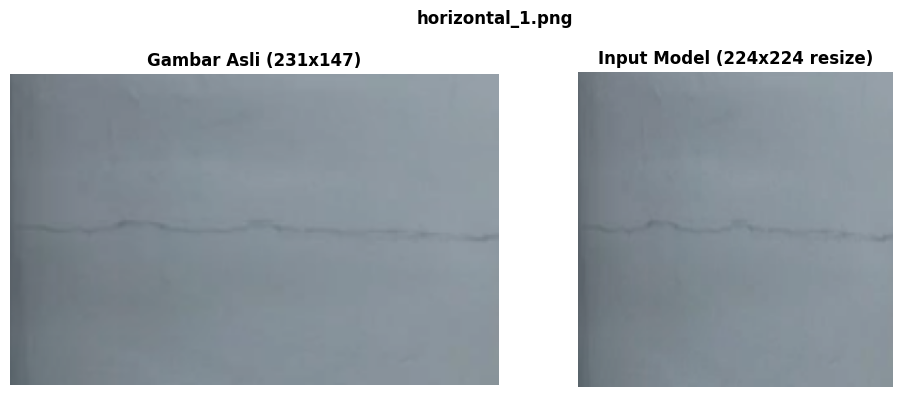

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Horizontal
  Keyakinan  : 74.09%
    Diagonal    :   0.32% 
    Horizontal  :  74.09% |||||||||||||||||||||||||||||
    Vertikal    :  25.59% ||||||||||

=== Uji Gambar: ./dataset/test/horizontal_2.png ===


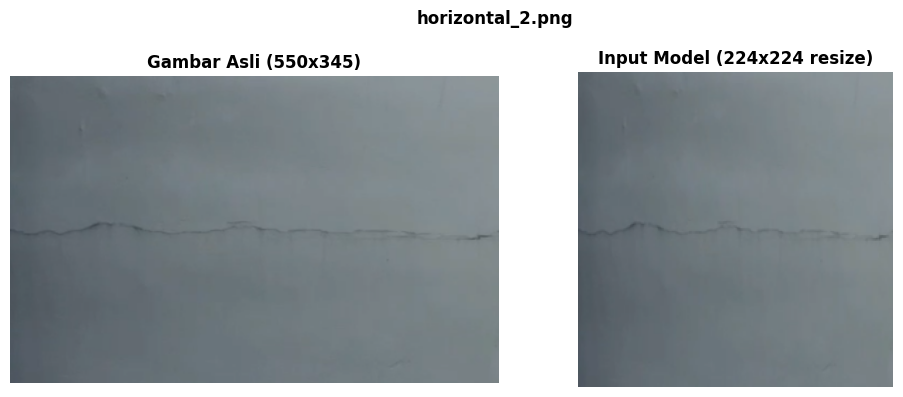

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Horizontal
  Keyakinan  : 75.00%
    Diagonal    :   0.01% 
    Horizontal  :  75.00% ||||||||||||||||||||||||||||||
    Vertikal    :  24.98% |||||||||

=== Uji Gambar: ./dataset/test/horizontal_3.png ===


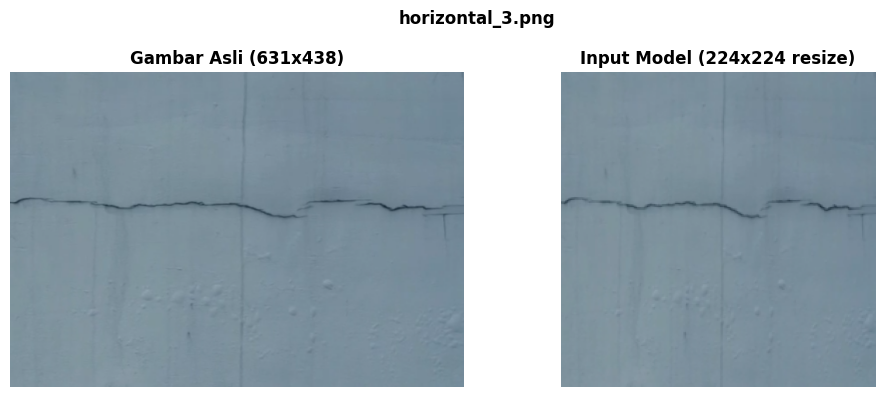

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Horizontal
  Keyakinan  : 70.98%
    Diagonal    :   0.38% 
    Horizontal  :  70.98% ||||||||||||||||||||||||||||
    Vertikal    :  28.64% |||||||||||

=== Uji Gambar: ./dataset/test/horizontal_4.png ===


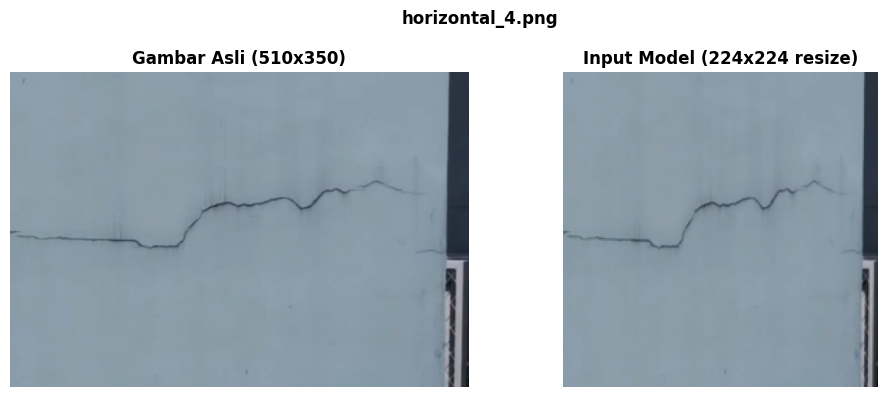

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Horizontal
  Keyakinan  : 51.04%
    Diagonal    :  10.09% ||||
    Horizontal  :  51.04% ||||||||||||||||||||
    Vertikal    :  38.88% |||||||||||||||

=== Uji Gambar: ./dataset/test/horizontal_5.png ===


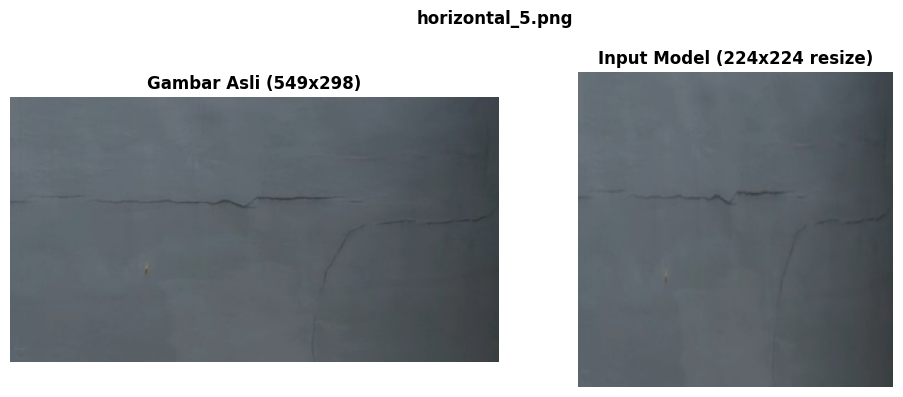

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Horizontal
  Keyakinan  : 74.18%
    Diagonal    :   0.91% 
    Horizontal  :  74.18% |||||||||||||||||||||||||||||
    Vertikal    :  24.91% |||||||||

=== Uji Gambar: ./dataset/test/vertikal_1.png ===


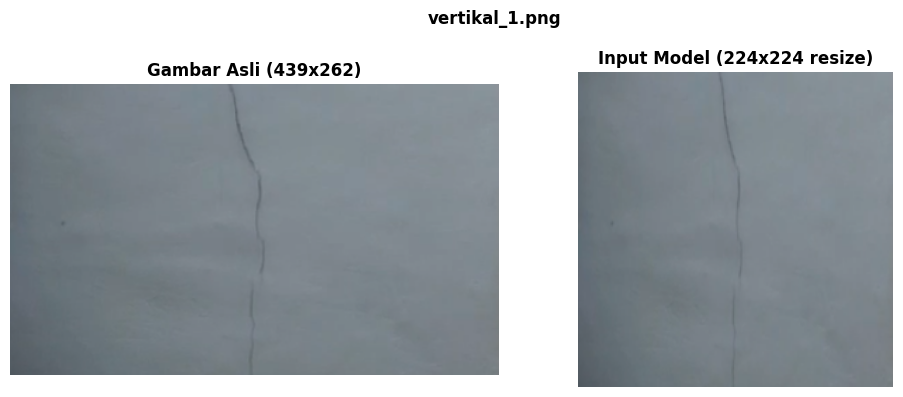

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Vertikal
  Keyakinan  : 75.17%
    Diagonal    :   7.37% ||
    Horizontal  :  17.46% ||||||
    Vertikal    :  75.17% ||||||||||||||||||||||||||||||

=== Uji Gambar: ./dataset/test/vertikal_2.png ===


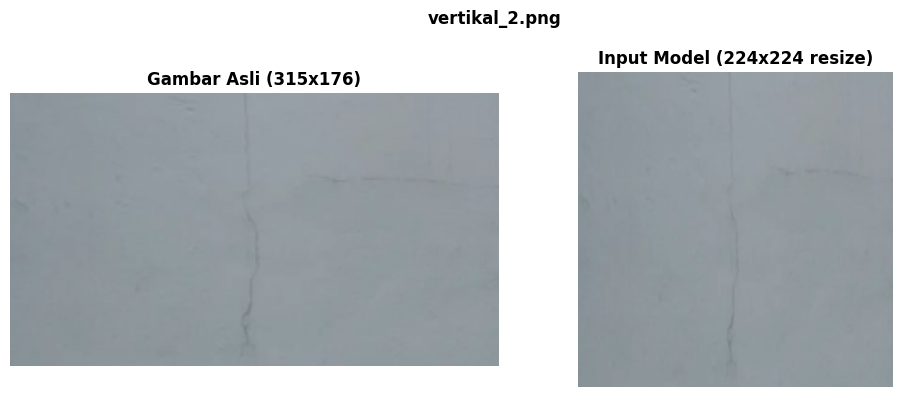

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Vertikal
  Keyakinan  : 75.97%
    Diagonal    :   3.51% |
    Horizontal  :  20.52% ||||||||
    Vertikal    :  75.97% ||||||||||||||||||||||||||||||

=== Uji Gambar: ./dataset/test/vertikal_3.png ===


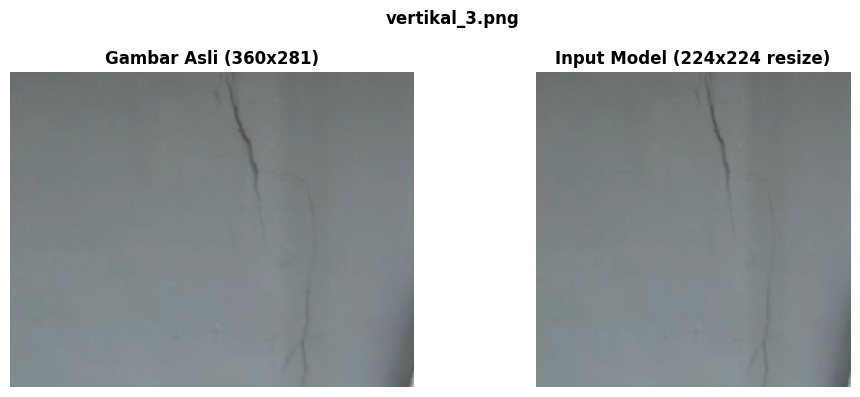

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Vertikal
  Keyakinan  : 74.67%
    Diagonal    :  13.09% |||||
    Horizontal  :  12.25% ||||
    Vertikal    :  74.67% |||||||||||||||||||||||||||||

=== Uji Gambar: ./dataset/test/vertikal_4.png ===


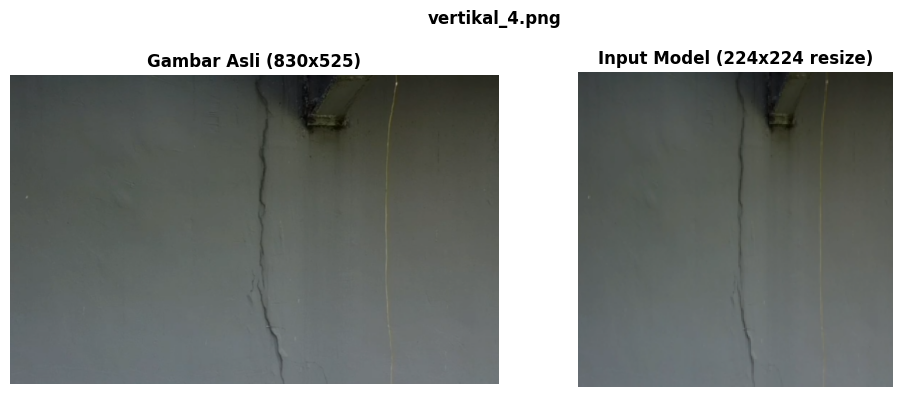

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Vertikal
  Keyakinan  : 70.47%
    Diagonal    :   4.62% |
    Horizontal  :  24.91% |||||||||
    Vertikal    :  70.47% ||||||||||||||||||||||||||||

=== Uji Gambar: ./dataset/test/vertikal_5.png ===


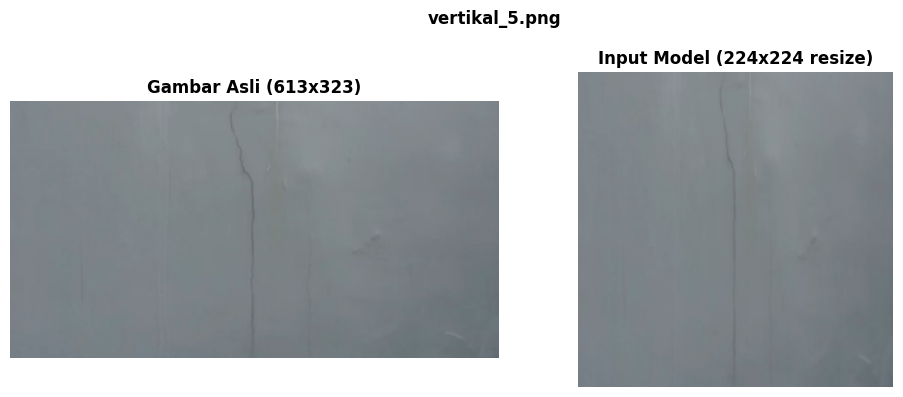

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Vertikal
  Keyakinan  : 73.77%
    Diagonal    :   4.12% |
    Horizontal  :  22.11% ||||||||
    Vertikal    :  73.77% |||||||||||||||||||||||||||||

=== Uji Gambar: ./dataset/test/diagonal_1.png ===


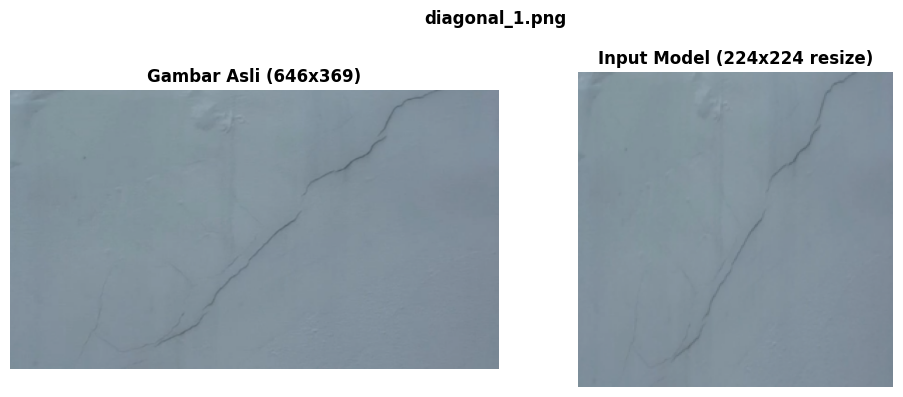

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Diagonal
  Keyakinan  : 95.01%
    Diagonal    :  95.01% ||||||||||||||||||||||||||||||||||||||
    Horizontal  :   0.41% 
    Vertikal    :   4.58% |

=== Uji Gambar: ./dataset/test/diagonal_2.png ===


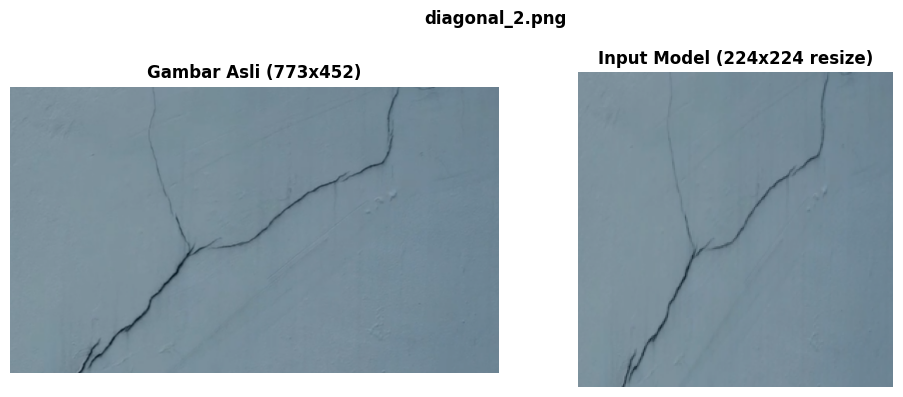

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Diagonal
  Keyakinan  : 98.17%
    Diagonal    :  98.17% |||||||||||||||||||||||||||||||||||||||
    Horizontal  :   0.73% 
    Vertikal    :   1.10% 

=== Uji Gambar: ./dataset/test/diagonal_3.png ===


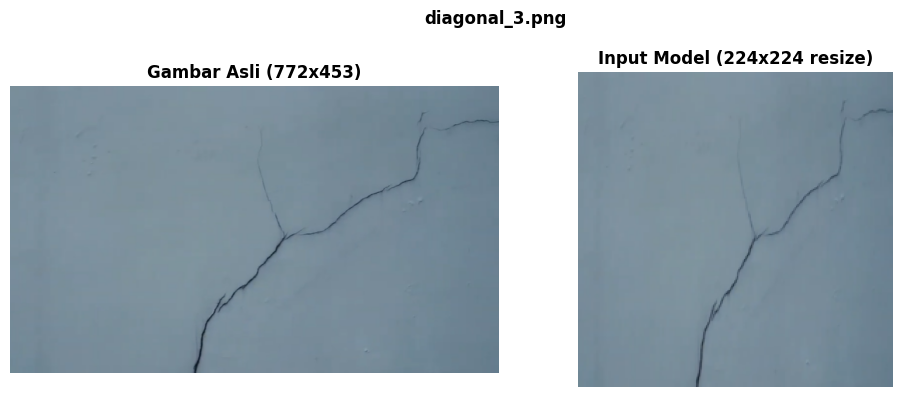

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Diagonal
  Keyakinan  : 93.75%
    Diagonal    :  93.75% |||||||||||||||||||||||||||||||||||||
    Horizontal  :   1.10% 
    Vertikal    :   5.15% ||

=== Uji Gambar: ./dataset/test/diagonal_4.png ===


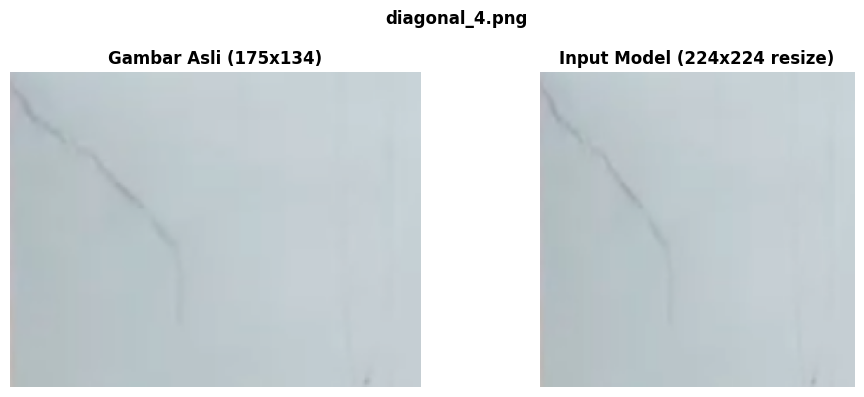

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Diagonal
  Keyakinan  : 72.71%
    Diagonal    :  72.71% |||||||||||||||||||||||||||||
    Horizontal  :   3.08% |
    Vertikal    :  24.21% |||||||||

=== Uji Gambar: ./dataset/test/diagonal_5.png ===


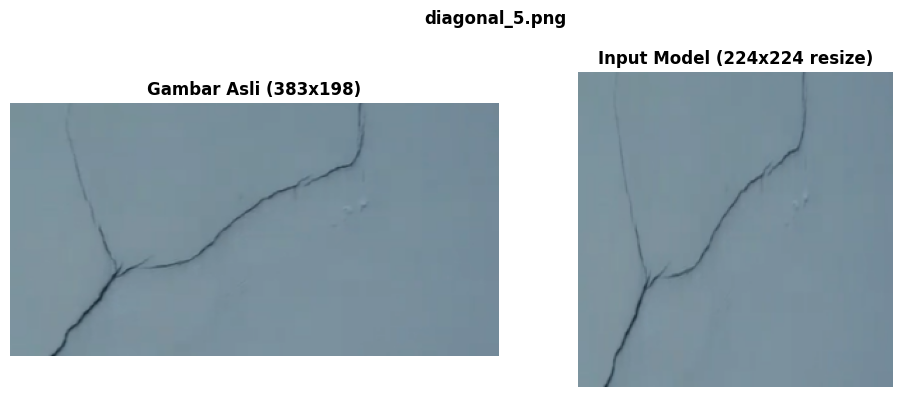

  Backend    : TFLite (cracksense_MobileNetV3Large.tflite)
  Metode     : TFLite + TTA (4 varian orientasi)
  Prediksi   : Diagonal
  Keyakinan  : 96.35%
    Diagonal    :  96.35% ||||||||||||||||||||||||||||||||||||||
    Horizontal  :   2.92% |
    Vertikal    :   0.73% 

RINGKASAN HASIL PREDIKSI
  horizontal_1.png               -> Horizontal   (74.1%)
  horizontal_2.png               -> Horizontal   (75.0%)
  horizontal_3.png               -> Horizontal   (71.0%)
  horizontal_4.png               -> Horizontal   (51.0%)
  horizontal_5.png               -> Horizontal   (74.2%)
  vertikal_1.png                 -> Vertikal     (75.2%)
  vertikal_2.png                 -> Vertikal     (76.0%)
  vertikal_3.png                 -> Vertikal     (74.7%)
  vertikal_4.png                 -> Vertikal     (70.5%)
  vertikal_5.png                 -> Vertikal     (73.8%)
  diagonal_1.png                 -> Diagonal     (95.0%)
  diagonal_2.png                 -> Diagonal     (98.2%)
  diagonal_3.png

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

TFLITE_PATH  = 'cracksense_MobileNetV3Large.tflite'
IMG_SIZE     = (224, 224)
CLASS_NAMES  = ['Diagonal', 'Horizontal', 'Vertikal']

TEST_IMAGE_PATHS = [
    './dataset/test/horizontal_1.png',
    './dataset/test/horizontal_2.png',
    './dataset/test/horizontal_3.png',
    './dataset/test/horizontal_4.png',
    './dataset/test/horizontal_5.png',


    './dataset/test/vertikal_1.png',
    './dataset/test/vertikal_2.png',
    './dataset/test/vertikal_3.png',
    './dataset/test/vertikal_4.png',
    './dataset/test/vertikal_5.png',
  

    './dataset/test/diagonal_1.png',
    './dataset/test/diagonal_2.png',
    './dataset/test/diagonal_3.png',
    './dataset/test/diagonal_4.png',
    './dataset/test/diagonal_5.png',
]


print(f'Loading TFLite model: {TFLITE_PATH}')
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f'  Input  : shape={input_details[0]["shape"]}, dtype={input_details[0]["dtype"]}')
print(f'  Output : shape={output_details[0]["shape"]}, dtype={output_details[0]["dtype"]}')
print()


# Fungsi preprocessing: simple resize ke 224x224
# jangan pakai center_crop! (penyebab bug Vertikal semua)

def preprocess_image_tflite(img_path):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
    img = tf.cast(img, tf.float32)
    
    # Simple resize langsung ke 224x224
    img = tf.image.resize(img, IMG_SIZE)
    
    # Preprocessing model-specific
    img = tf.keras.applications.mobilenet_v3.preprocess_input(img)
    
    img = tf.expand_dims(img, axis=0)
    return img.numpy().astype(np.float32)


def tflite_predict_single(img_np):
    interpreter.set_tensor(input_details[0]['index'], img_np)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    return output[0]

def tflite_predict_with_tta(img_path):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
    img = tf.cast(img, tf.float32)
    img_resized = tf.image.resize(img, IMG_SIZE)

    variants = [
        img_resized,
        tf.image.flip_left_right(img_resized),
        tf.image.flip_up_down(img_resized),
        tf.image.rot90(img_resized, k=1),
    ]

    preds_all = []
    for v in variants:
        v_norm = tf.keras.applications.mobilenet_v3.preprocess_input(v)
        v_np   = tf.expand_dims(v_norm, 0).numpy().astype(np.float32)
        p = tflite_predict_single(v_np)
        preds_all.append(p)

    return np.mean(preds_all, axis=0)


def predict_custom_images_tflite(image_paths, use_tta=True):
    results = []
    for test_image_path in image_paths:
        print(f'\n=== Uji Gambar: {test_image_path} ===')

        if not os.path.exists(test_image_path):
            print(f'  [!] File tidak ditemukan!')
            results.append({'path': test_image_path, 'prediction': None, 'confidence': None, 'probabilities': None})
            continue

        pil_img = Image.open(test_image_path).convert('RGB')
        img_w, img_h = pil_img.size
        img_display = np.array(pil_img.resize(IMG_SIZE[::-1]))

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(pil_img)
        axes[0].set_title(f'Gambar Asli ({img_w}x{img_h})', fontweight='bold')
        axes[0].axis('off')
        axes[1].imshow(img_display)
        axes[1].set_title(f'Input Model (224x224 resize)', fontweight='bold')
        axes[1].axis('off')
        plt.suptitle(os.path.basename(test_image_path), fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

        if use_tta:
            preds  = tflite_predict_with_tta(test_image_path)
            metode = 'TFLite + TTA (4 varian orientasi)'
        else:
            img_np = preprocess_image_tflite(test_image_path)
            preds  = tflite_predict_single(img_np)
            metode = 'TFLite single inference'

        pred_idx   = int(np.argmax(preds))
        confidence = float(preds[pred_idx] * 100)
        pred_class = CLASS_NAMES[pred_idx]

        print(f'  Backend    : TFLite ({TFLITE_PATH})')
        print(f'  Metode     : {metode}')
        print(f'  Prediksi   : {pred_class}')
        print(f'  Keyakinan  : {confidence:.2f}%')
        for i, cls in enumerate(CLASS_NAMES):
            bar = '|' * int(preds[i] * 40)
            print(f'    {cls:12s}: {preds[i]*100:6.2f}% {bar}')

        results.append({
            'path':          test_image_path,
            'prediction':    pred_class,
            'confidence':    confidence,
            'probabilities': {cls: float(preds[i]*100) for i, cls in enumerate(CLASS_NAMES)}
        })

    return results

print('=' * 60)
print('INFERENSI TFLITE - GAMBAR CUSTOM')
print('=' * 60)
print(f'Model : {TFLITE_PATH}')
print()

custom_results = predict_custom_images_tflite(TEST_IMAGE_PATHS, use_tta=True)

print()
print('=' * 60)
print('RINGKASAN HASIL PREDIKSI')
print('=' * 60)
for r in custom_results:
    if r['prediction'] is not None:
        fname = os.path.basename(r['path'])
        print(f'  {fname:30s} -> {r["prediction"]:12s} ({r["confidence"]:.1f}%)')



## Simpan Model & Konversi ke TFLite

In [14]:
model.save(f'cracksense_{MODEL_NAME}.keras')
print(f'Model disimpan: cracksense_{MODEL_NAME}.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_filename = f'cracksense_{MODEL_NAME}.tflite'
with open(tflite_filename, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_filename) / (1024*1024)
print(f'TFLite disimpan: {tflite_filename} ({size_mb:.2f} MB)')

Model disimpan: cracksense_MobileNetV3Large.keras
INFO:tensorflow:Assets written to: C:\Users\FARELL\AppData\Local\Temp\tmpqqix2wfc\assets


INFO:tensorflow:Assets written to: C:\Users\FARELL\AppData\Local\Temp\tmpqqix2wfc\assets


Saved artifact at 'C:\Users\FARELL\AppData\Local\Temp\tmpqqix2wfc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_203')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2045825381200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045825382544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045825381968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045825382352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045825381584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045825382160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045825381392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045825380816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045825380624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045825381776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  